# Births with Varying Crude Birth Rate

## Purpose

This notebook exercises `BirthsByCBR` and `NonDiseaseMortality` in three
birth/death balance scenarios:

1. **Single node, constant CBR = CDR** — population should remain flat
   (within stochastic noise).
2. **Two nodes, different CBRs and CDRs** — each node has its own per-tick,
   per-node birth and mortality rate.
3. **Single node, declining CBR with fixed CDR** — population grows while
   CBR > CDR, then shrinks once the rates cross.

All three scenarios use **β = 0** (no disease transmission) so that $N(t)$
tracks births and deaths alone.

Unlike `ConstantPopBirths` (which mirrors the per-tick death count into the
`S` compartment and so keeps $N$ exactly constant by construction),
**`BirthsByCBR` is an independent demographic process** — it accepts its
own per-tick, per-node CBR and draws a Poisson number of births from
`N × r_birth[tick]`.  That makes scenarios where births ≠ deaths (the
whole point of this notebook) trivial to express: the third scenario in
particular drops the subclass workaround that the previous
`ConstantPopBirths`-based version of this notebook needed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.vitaldynamics import NonDiseaseMortality, BirthsByCBR
import laser.cohorts.SEIR as SEIR

In [ ]:
# =============================================================================
# Scenario 1 — single node, constant CBR = CDR = 30 per 1000/yr
# Births and deaths are independent processes, both driven by the same rate;
# N should stay flat (within stochastic noise).
# =============================================================================
N1       = 100_000
CDR1     = 30
CBR1     = 30
nticks1  = 10 * 365
n_nodes1 = 1

r_mort1  = CDR1 / 1000 / 365
r_birth1 = CBR1 / 1000 / 365

scenario1 = grid(M=1, N=1)
scenario1["S"] = N1
scenario1["E"] = 0
scenario1["I"] = 0
scenario1["R"] = 0

params1 = PropertySet({"nticks": nticks1})
model1  = Model(scenario1, params1)

betas1          = ValuesMap.from_scalar(0.0,       nticks1, n_nodes1)
r_progressions1 = ValuesMap.from_scalar(1 / 5,    nticks1, n_nodes1)
r_recoveries1   = ValuesMap.from_scalar(1 / 7,    nticks1, n_nodes1)

ndm1   = NonDiseaseMortality(model1, r_mortality=r_mort1)
bcbr1  = BirthsByCBR(model1, r_birth=r_birth1)

model1.components = [
    SEIR.Susceptible(model1),
    SEIR.Exposed(model1, r_progression=r_progressions1),
    SEIR.Infectious(model1, r_recovery=r_recoveries1),
    SEIR.Recovered(model1),
    ndm1,
    bcbr1,
    SEIR.Transmission(model1, beta=betas1),
]

model1.run()

N1_ts = (
    model1.states.S[:, 0]
    + model1.states.E[:, 0]
    + model1.states.I[:, 0]
    + model1.states.R[:, 0]
)

t1 = np.arange(nticks1 + 1) / 365

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, N1_ts, color="steelblue", linewidth=0.8)
ax.axhline(N1, color="firebrick", linestyle="--", linewidth=1.2, label=f"Initial N = {N1:,}")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.set_title(f"Scenario 1 — single node, CBR = CDR = {CDR1}/1000/yr (N should be flat)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Scenario 1 max deviation : {np.abs(N1_ts - N1).max():,}")
print(f"Scenario 1 final N       : {int(N1_ts[-1]):,}  (started at {N1:,})")

In [ ]:
# =============================================================================
# Scenario 2 — two nodes with their own per-node CBR and CDR
# Node 0: N=100_000, CBR = CDR = 10 per 1000/yr   (small population, low rate)
# Node 1: N=200_000, CBR = CDR = 30 per 1000/yr   (larger population, high rate)
# Each node uses an independent per-tick, per-node rate; both stay flat.
# =============================================================================
N2_node0 = 100_000
N2_node1 = 200_000
nticks2  = 10 * 365
n_nodes2 = 2

# Per-node mortality and birth rates: both (nticks, nnodes)
r_mort_2d  = np.zeros((nticks2, n_nodes2))
r_birth_2d = np.zeros((nticks2, n_nodes2))
r_mort_2d[:, 0]  = 10 / 1000 / 365
r_mort_2d[:, 1]  = 30 / 1000 / 365
r_birth_2d[:, 0] = 10 / 1000 / 365
r_birth_2d[:, 1] = 30 / 1000 / 365

scenario2 = grid(M=2, N=1)
scenario2.loc[0, "S"] = N2_node0
scenario2.loc[1, "S"] = N2_node1
scenario2["E"] = 0
scenario2["I"] = 0
scenario2["R"] = 0

params2 = PropertySet({"nticks": nticks2})
model2  = Model(scenario2, params2)

betas2          = ValuesMap.from_scalar(0.0,    nticks2, n_nodes2)
r_progressions2 = ValuesMap.from_scalar(1 / 5, nticks2, n_nodes2)
r_recoveries2   = ValuesMap.from_scalar(1 / 7, nticks2, n_nodes2)

ndm2  = NonDiseaseMortality(model2, r_mortality=r_mort_2d)
bcbr2 = BirthsByCBR(model2, r_birth=r_birth_2d)

model2.components = [
    SEIR.Susceptible(model2),
    SEIR.Exposed(model2, r_progression=r_progressions2),
    SEIR.Infectious(model2, r_recovery=r_recoveries2),
    SEIR.Recovered(model2),
    ndm2,
    bcbr2,
    SEIR.Transmission(model2, beta=betas2),
]

model2.run()

def total_N_node(model, node):
    return (
        model.states.S[:, node]
        + model.states.E[:, node]
        + model.states.I[:, node]
        + model.states.R[:, node]
    )

N2_node0_ts = total_N_node(model2, 0)
N2_node1_ts = total_N_node(model2, 1)
t2 = np.arange(nticks2 + 1) / 365

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, ts, N_init, rate_val, node_idx in zip(
    axes,
    [N2_node0_ts, N2_node1_ts],
    [N2_node0, N2_node1],
    [10, 30],
    [0, 1],
):
    ax.plot(t2, ts, color="steelblue", linewidth=0.8)
    ax.axhline(N_init, color="firebrick", linestyle="--", linewidth=1.2,
               label=f"Initial N = {N_init:,}")
    ax.set_title(f"Node {node_idx} — CBR = CDR = {rate_val}/1000/yr")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.legend(fontsize=8)

fig.suptitle("Scenario 2 — two nodes, independent per-node CBR and CDR (both flat)")
plt.tight_layout()
plt.show()

print(f"Node 0 max deviation : {np.abs(N2_node0_ts - N2_node0).max():,}")
print(f"Node 1 max deviation : {np.abs(N2_node1_ts - N2_node1).max():,}")

In [ ]:
# =============================================================================
# Scenario 3 — declining CBR with fixed CDR
# The death rate is held constant at CDR = 20 per 1000/yr.
# The birth rate declines linearly from 40 down to 10 per 1000/yr over the
# 20-year run.  At year 10 the two lines cross — until that point CBR > CDR
# so the population grows; after, CBR < CDR so the population shrinks.
#
# This is the scenario that motivates `BirthsByCBR`: a time-varying per-tick
# birth rate is just a (nticks, nnodes) array; no subclassing required.
# =============================================================================
N3      = 100_000
CDR3    = 20              # fixed death rate (per 1000/yr)
nticks3 = 20 * 365        # 20 years
n_nodes3 = 1

# r_mortality is constant in time
r_mort_3 = CDR3 / 1000 / 365

# r_birth declines linearly from 40 to 10 per 1000/yr; shape (nticks, nnodes)
cbr_trend = np.linspace(40, 10, nticks3)               # CBR in births/1000/yr
r_birth_3 = (cbr_trend / 1000 / 365)[:, None]          # shape (nticks, 1)

scenario3 = grid(M=1, N=1)
scenario3["S"] = N3
scenario3["E"] = 0
scenario3["I"] = 0
scenario3["R"] = 0

params3 = PropertySet({"nticks": nticks3})
model3  = Model(scenario3, params3)

betas3          = ValuesMap.from_scalar(0.0,    nticks3, n_nodes3)
r_progressions3 = ValuesMap.from_scalar(1 / 5, nticks3, n_nodes3)
r_recoveries3   = ValuesMap.from_scalar(1 / 7, nticks3, n_nodes3)

ndm3  = NonDiseaseMortality(model3, r_mortality=r_mort_3)
bcbr3 = BirthsByCBR(model3, r_birth=r_birth_3)

model3.components = [
    SEIR.Susceptible(model3),
    SEIR.Exposed(model3, r_progression=r_progressions3),
    SEIR.Infectious(model3, r_recovery=r_recoveries3),
    SEIR.Recovered(model3),
    ndm3,
    bcbr3,
    SEIR.Transmission(model3, beta=betas3),
]

model3.run()

N3_ts = (
    model3.states.S[:, 0]
    + model3.states.E[:, 0]
    + model3.states.I[:, 0]
    + model3.states.R[:, 0]
)
t3 = np.arange(nticks3 + 1) / 365

# CBR crosses CDR (=20) at year 10
crossover_year = 10

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={"height_ratios": [1, 2]})

# Top: the CBR and CDR rate schedule
axes[0].plot(np.arange(nticks3) / 365, cbr_trend, color="forestgreen", linewidth=1.2, label="CBR (declining)")
axes[0].axhline(CDR3, color="firebrick", linestyle="--", linewidth=1.2, label=f"CDR = {CDR3} (constant)")
axes[0].axvline(crossover_year, color="orange", linestyle=":", linewidth=1.5)
axes[0].set_ylabel("Births / 1000 / yr")
axes[0].set_title("Scenario 3 — rate schedule")
axes[0].legend(fontsize=9)

# Bottom: resulting population
axes[1].plot(t3, N3_ts, color="steelblue", linewidth=1.0, label="N(t)")
axes[1].axhline(N3, color="gray", linestyle="--", linewidth=0.8, label=f"Initial N = {N3:,}")
axes[1].axvline(crossover_year, color="orange", linestyle=":", linewidth=1.5,
                label="CBR = CDR crossover")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Population")
axes[1].set_title("Population grows while CBR > CDR, then shrinks once they cross")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Initial N : {int(N3_ts[0]):,}")
print(f"Peak N    : {int(N3_ts.max()):,}  at year {t3[N3_ts.argmax()]:.1f}")
print(f"Final N   : {int(N3_ts[-1]):,}")
print(f"Net change: {int(N3_ts[-1] - N3_ts[0]):+,}")

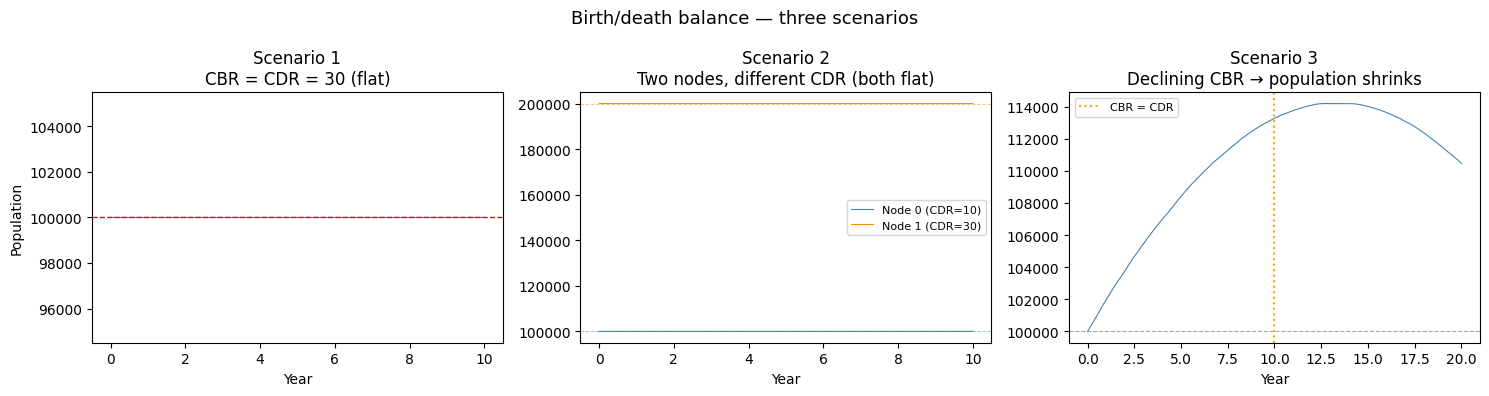

In [5]:
# --- Summary: all three scenarios in one figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scenario 1
axes[0].plot(t1, N1_ts, color="steelblue", linewidth=0.8)
axes[0].axhline(N1, color="firebrick", linestyle="--", linewidth=1.0)
axes[0].set_title("Scenario 1\nCBR = CDR = 30 (flat)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Population")

# Scenario 2 — overlay both nodes
axes[1].plot(t2, N2_node0_ts, color="steelblue",  linewidth=0.8, label="Node 0 (CDR=10)")
axes[1].plot(t2, N2_node1_ts, color="darkorange",  linewidth=0.8, label="Node 1 (CDR=30)")
axes[1].axhline(N2_node0, color="steelblue",  linestyle="--", linewidth=0.7, alpha=0.5)
axes[1].axhline(N2_node1, color="darkorange",  linestyle="--", linewidth=0.7, alpha=0.5)
axes[1].set_title("Scenario 2\nTwo nodes, different CDR (both flat)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)

# Scenario 3
axes[2].plot(t3, N3_ts, color="steelblue", linewidth=0.8)
axes[2].axhline(N3, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].axvline(crossover_year, color="orange", linestyle=":", linewidth=1.5,
                label="CBR = CDR")
axes[2].set_title("Scenario 3\nDeclining CBR → population shrinks")
axes[2].set_xlabel("Year")
axes[2].legend(fontsize=8)

fig.suptitle("Birth/death balance — three scenarios", fontsize=13)
plt.tight_layout()
plt.show()